# SkillsBench RQ1 Analysis

这个 notebook 只分析 `skillsbench` benchmark 下已经跑出来的 `MiniMax-M2.5` 结果。

当前范围：
- 只看 SkillsBench
- 只看 MiniMax
- 不包含 GPT 模型对比
- 同时覆盖性能分析和成本分析


In [1]:
import json
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("future.no_silent_downcasting", True)

AGGREGATED_RESULTS_PATH = Path("/home/nudt/lirui/skill_study/skill/analysis/rq1/aggregated_results.json")

TOKEN_PRICING_PATH = Path("/home/nudt/lirui/skill_study/skill/analysis/rq1/token_pricing_cny_per_mtoken.json")
TOKEN_PRICING_CNY_PER_MTOKEN = json.loads(TOKEN_PRICING_PATH.read_text(encoding="utf-8"))
PRICE_CNY_PER_MTOKEN = TOKEN_PRICING_CNY_PER_MTOKEN["MiniMax-M2.5"]

JOB_ROOT = Path("/home/nudt/lirui/skill_study/jobs")


In [2]:
if not AGGREGATED_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Aggregated results file not found: {AGGREGATED_RESULTS_PATH}")

print(f"Aggregated results: {AGGREGATED_RESULTS_PATH}")


Aggregated results: /home/nudt/lirui/skill_study/skill/analysis/rq1/aggregated_results.json


In [3]:
with AGGREGATED_RESULTS_PATH.open("r", encoding="utf-8") as f:
    data = json.load(f)

tasks = data.get("tasks") or []
efficiency = data.get("efficiency") or {}
model = data.get("model", "unknown")
run_id = data.get("run_id", "")


def has_token_data(task):
    usage = task.get("usage") or {}
    if any(float(usage.get(key) or 0) > 0 for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]):
        return True
    if any(float(v or 0) > 0 for v in (task.get("prompt_tokens_by_attempt") or [])):
        return True
    if any(float(v or 0) > 0 for v in (task.get("completion_tokens_by_attempt") or [])):
        return True
    for attempt in task.get("attempts") or []:
        attempt_usage = ((attempt.get("execution") or {}).get("usage") or attempt.get("usage") or {})
        if any(float(attempt_usage.get(key) or 0) > 0 for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]):
            return True
    return False


def normalize_zero_token_task(task):
    normalized = dict(task)
    usage = dict(normalized.get("usage") or {})
    for key in ["input_tokens", "output_tokens", "cache_read_tokens", "cache_write_tokens", "cache_tokens", "total_tokens"]:
        usage[key] = float(usage.get(key) or 0)
    normalized["usage"] = usage
    if not normalized.get("prompt_tokens_by_attempt"):
        normalized["prompt_tokens_by_attempt"] = []
    if not normalized.get("completion_tokens_by_attempt"):
        normalized["completion_tokens_by_attempt"] = []
    normalized["token_imputed_as_zero"] = True
    return normalized


def detect_failure_reason(task):
    trial = task.get("source_trial")
    job = task.get("source_job")
    if not trial or not job:
        return "unknown", "missing source_trial/source_job"

    exception_path = JOB_ROOT / job / trial / "exception.txt"
    if not exception_path.exists():
        return "unknown", "missing exception.txt"

    text = exception_path.read_text(encoding="utf-8", errors="ignore")
    if "APITimeoutError" in text or "ConnectTimeout" in text or "Request timed out" in text:
        return "LLM API timeout", "APITimeoutError / ConnectTimeout / Request timed out"
    if "InternalServerError" in text or "Error code: 500" in text or "520 (1000)" in text:
        return "LLM API 500/520", "InternalServerError / 500 / 520 (1000)"
    if "context window exceeds limit (2013)" in text:
        return "Context limit", "BadRequestError: context window exceeds limit (2013)"
    if "TimeoutError" in text and "run_agent" in text:
        return "Agent timeout", "TimeoutError / asyncio.wait_for(agent.run(...))"
    return "Other", "See exception.txt"


def compute_cost(usage):
    usage = usage or {}
    return (
        float(usage.get("input_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["input_tokens"]
        + float(usage.get("output_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["output_tokens"]
        + float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["cache_read_tokens"]
        + float(usage.get("cache_write_tokens") or 0) / 1_000_000 * PRICE_CNY_PER_MTOKEN["cache_write_tokens"]
    )


def build_efficiency(tasks):
    per_task = []
    total_tokens = 0.0
    total_input_tokens = 0.0
    total_output_tokens = 0.0
    total_cache_tokens = 0.0
    total_cache_read_tokens = 0.0
    total_cache_write_tokens = 0.0
    total_cost_usd = 0.0
    total_requests = 0
    total_execution_time_seconds = 0.0

    for task in tasks:
        usage = task.get("usage") or {}
        task_total_tokens = float(usage.get("total_tokens") or 0)
        task_input_tokens = float(usage.get("input_tokens") or 0)
        task_output_tokens = float(usage.get("output_tokens") or 0)
        task_cache_read_tokens = float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0)
        task_cache_write_tokens = float(usage.get("cache_write_tokens") or 0)
        task_cost_usd = float(usage.get("cost_usd") or 0)
        task_requests = int(usage.get("request_count") or 0)
        score = float(((task.get("grading") or {}).get("score")) or 0)
        passed = bool(task.get("status") == "success")

        total_tokens += task_total_tokens
        total_input_tokens += task_input_tokens
        total_output_tokens += task_output_tokens
        total_cache_tokens += task_cache_read_tokens
        total_cache_read_tokens += task_cache_read_tokens
        total_cache_write_tokens += task_cache_write_tokens
        total_cost_usd += task_cost_usd
        total_requests += task_requests
        total_execution_time_seconds += float(task.get("execution_time") or 0)

        per_task.append({
            "task_id": task.get("task_id", ""),
            "score": score,
            "passed": passed,
            "total_tokens": task_total_tokens,
            "cost_usd": task_cost_usd,
            "tokens_per_score_point": (task_total_tokens / score) if score > 0 else None,
            "tokens_per_success": task_total_tokens if passed else None,
        })

    task_count = len(tasks)
    success_count = sum(1 for task in tasks if task.get("status") == "success")
    total_score = sum(float(((task.get("grading") or {}).get("score")) or 0) for task in tasks)
    success_at_k = {}
    max_attempts = max((int(task.get("attempt_count") or 0) for task in tasks), default=0)
    for k in range(1, max_attempts + 1):
        success_at_k[str(k)] = round(
            sum(1 for task in tasks if (task.get("first_success_attempt") is not None and int(task.get("first_success_attempt") or 0) <= k)) / max(task_count, 1),
            6,
        )

    return {
        "total_tokens": total_tokens,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "total_cache_tokens": total_cache_tokens,
        "total_cache_read_tokens": total_cache_read_tokens,
        "total_cache_write_tokens": total_cache_write_tokens,
        "total_cost_usd": total_cost_usd,
        "total_requests": total_requests,
        "total_execution_time_seconds": total_execution_time_seconds,
        "tasks_with_usage_data": sum(1 for task in tasks if has_token_data(task)),
        "tokens_per_task": (total_tokens / task_count) if task_count else None,
        "cost_per_task_usd": (total_cost_usd / task_count) if task_count else None,
        "score_per_1k_tokens": (total_score / (total_tokens / 1000.0)) if total_tokens else None,
        "score_per_dollar": (total_score / total_cost_usd) if total_cost_usd else None,
        "success_rate": (success_count / task_count) if task_count else None,
        "success_per_1k_tokens": (success_count / (total_tokens / 1000.0)) if total_tokens else None,
        "success_per_dollar": (success_count / total_cost_usd) if total_cost_usd else None,
        "success_at_k": success_at_k,
        "per_task": per_task,
    }


efficiency = build_efficiency(tasks)
task_rows = []
attempt_rows = []

for task in tasks:
    attempts = task.get("attempts") or []
    top_usage = task.get("usage") or {}
    task_cost_cny = compute_cost(top_usage)
    success = task.get("status") == "success"
    first_success_attempt = task.get("first_success_attempt")
    failure_reason, failure_evidence = detect_failure_reason(task) if not success else ("", "")

    task_rows.append({
        "task_id": task.get("task_id", ""),
        "status": task.get("status", ""),
        "success": success,
        "timed_out": bool(task.get("timed_out", False)),
        "attempt_count": int(task.get("attempt_count") or len(attempts) or 0),
        "attempt_records": len(attempts),
        "first_success_attempt": int(first_success_attempt) if first_success_attempt else pd.NA,
        "llm_rounds": int(task.get("llm_rounds") or 0),
        "execution_time_sec": float(task.get("execution_time") or 0),
        "reward": float(((task.get("grading") or {}).get("breakdown") or {}).get("reward") or 0),
        "input_tokens": float(top_usage.get("input_tokens") or 0),
        "output_tokens": float(top_usage.get("output_tokens") or 0),
        "cache_read_tokens": float(top_usage.get("cache_read_tokens") or top_usage.get("cache_tokens") or 0),
        "cache_write_tokens": float(top_usage.get("cache_write_tokens") or 0),
        "total_tokens": float(top_usage.get("total_tokens") or 0),
        "cost_cny": task_cost_cny,
        "cost_per_success_cny": task_cost_cny if success else pd.NA,
        "no_effective_attempt": (int(task.get("attempt_count") or 0) == 0 and len(attempts) == 0),
        "failure_reason": failure_reason,
        "failure_evidence": failure_evidence,
        "source_job": task.get("source_job", ""),
        "source_trial": task.get("source_trial", ""),
    })

    for attempt in attempts:
        execution = attempt.get("execution") or {}
        verifier = attempt.get("verifier") or {}
        usage = execution.get("usage") or attempt.get("usage") or {}
        reward = verifier.get("reward")
        attempt_rows.append({
            "task_id": task.get("task_id", ""),
            "attempt": int(attempt.get("attempt") or 0),
            "llm_rounds": int(execution.get("llm_rounds") or 0),
            "execution_time_sec": float(execution.get("execution_time") or 0),
            "input_tokens": float(usage.get("input_tokens") or 0),
            "output_tokens": float(usage.get("output_tokens") or 0),
            "cache_read_tokens": float(usage.get("cache_read_tokens") or usage.get("cache_tokens") or 0),
            "cache_write_tokens": float(usage.get("cache_write_tokens") or 0),
            "total_tokens": float(usage.get("total_tokens") or 0),
            "reward": float(reward) if reward is not None else pd.NA,
            "passed": reward == 1.0,
            "cost_cny": compute_cost(usage),
        })


df_tasks = pd.DataFrame(task_rows).sort_values(["success", "cost_cny", "task_id"], ascending=[False, False, True]).reset_index(drop=True)
df_attempts = pd.DataFrame(attempt_rows).sort_values(["attempt", "task_id"]).reset_index(drop=True)

print(f"Model: {model}")
print(f"Run ID: {run_id}")
print(f"Tasks: {len(df_tasks)}")
print(f"Attempt records: {len(df_attempts)}")
print(f"Tasks with zero tokens imputed due to no effective attempt: {sum(bool(task.get('token_imputed_as_zero', False)) for task in tasks)}")
print("All tasks have token data (including zero-imputed no-attempt tasks).")


Model: unknown
Run ID: 
Tasks: 87
Attempt records: 167
Tasks with zero tokens imputed due to no effective attempt: 0
All tasks have token data (including zero-imputed no-attempt tasks).


In [4]:
success_cost_cny = float(df_tasks[df_tasks["success"]]["cost_cny"].sum())
failed_cost_cny = float(df_tasks[~df_tasks["success"]]["cost_cny"].sum())
timeout_cost_cny = float(df_tasks[df_tasks["timed_out"]]["cost_cny"].sum())
error_non_timeout_cost_cny = float(df_tasks[(~df_tasks["success"]) & (~df_tasks["timed_out"])]["cost_cny"].sum())

summary = {
    "task_count": int(len(df_tasks)),
    "success_count": int(df_tasks["success"].sum()),
    "failure_count": int((~df_tasks["success"]).sum()),
    "success_rate": float(df_tasks["success"].mean()),
    "no_effective_attempt_failures": int(df_tasks["no_effective_attempt"].sum()),
    "mean_attempt_count": float(df_tasks["attempt_count"].mean()),
    "median_attempt_count": float(df_tasks["attempt_count"].median()),
    "mean_execution_time_sec": float(df_tasks["execution_time_sec"].mean()),
    "median_execution_time_sec": float(df_tasks["execution_time_sec"].median()),
    "total_cost_cny": float(df_tasks["cost_cny"].sum()),
    "success_cost_cny": success_cost_cny,
    "failed_cost_cny": failed_cost_cny,
    "timeout_cost_cny": timeout_cost_cny,
    "error_non_timeout_cost_cny": error_non_timeout_cost_cny,
    "mean_cost_per_task_cny": float(df_tasks["cost_cny"].mean()),
    "median_cost_per_task_cny": float(df_tasks["cost_cny"].median()),
}

for key, value in summary.items():
    print(f"{key}: {value}")

print("\nTop-level efficiency fields:")
for key, value in efficiency.items():
    if key != "per_task":
        print(f"  {key}: {value}")

print("\nSuccess by first_success_attempt:")
first_success = (
    df_tasks[df_tasks["success"]]
    .groupby("first_success_attempt")
    .size()
    .rename("tasks")
    .reset_index()
)
display(first_success)


task_count: 87
success_count: 36
failure_count: 51
success_rate: 0.41379310344827586
no_effective_attempt_failures: 1
mean_attempt_count: 1.9195402298850575
median_attempt_count: 2.0
mean_execution_time_sec: 1322.6884187471264
median_execution_time_sec: 1056.0
total_cost_cny: 234.32881420799998
success_cost_cny: 94.43519769599997
failed_cost_cny: 139.893616512
timeout_cost_cny: 117.687948192
error_non_timeout_cost_cny: 22.20566832
mean_cost_per_task_cny: 2.6934346460689653
median_cost_per_task_cny: 1.870232256

Top-level efficiency fields:
  total_tokens: 256122633.0
  total_input_tokens: 130952145.0
  total_output_tokens: 1774237.0
  total_cache_tokens: 123396251.0
  total_cache_read_tokens: 123396251.0
  total_cache_write_tokens: 0.0
  total_cost_usd: 0.0
  total_requests: 4002
  total_execution_time_seconds: 115073.892431
  tasks_with_usage_data: 84
  tokens_per_task: 2943938.3103448274
  cost_per_task_usd: 0.0
  score_per_1k_tokens: 0.00014055766793557835
  score_per_dollar: None
 

,first_success_attempt,tasks
0,1,9
1,2,21
2,3,2
3,4,3
4,6,1


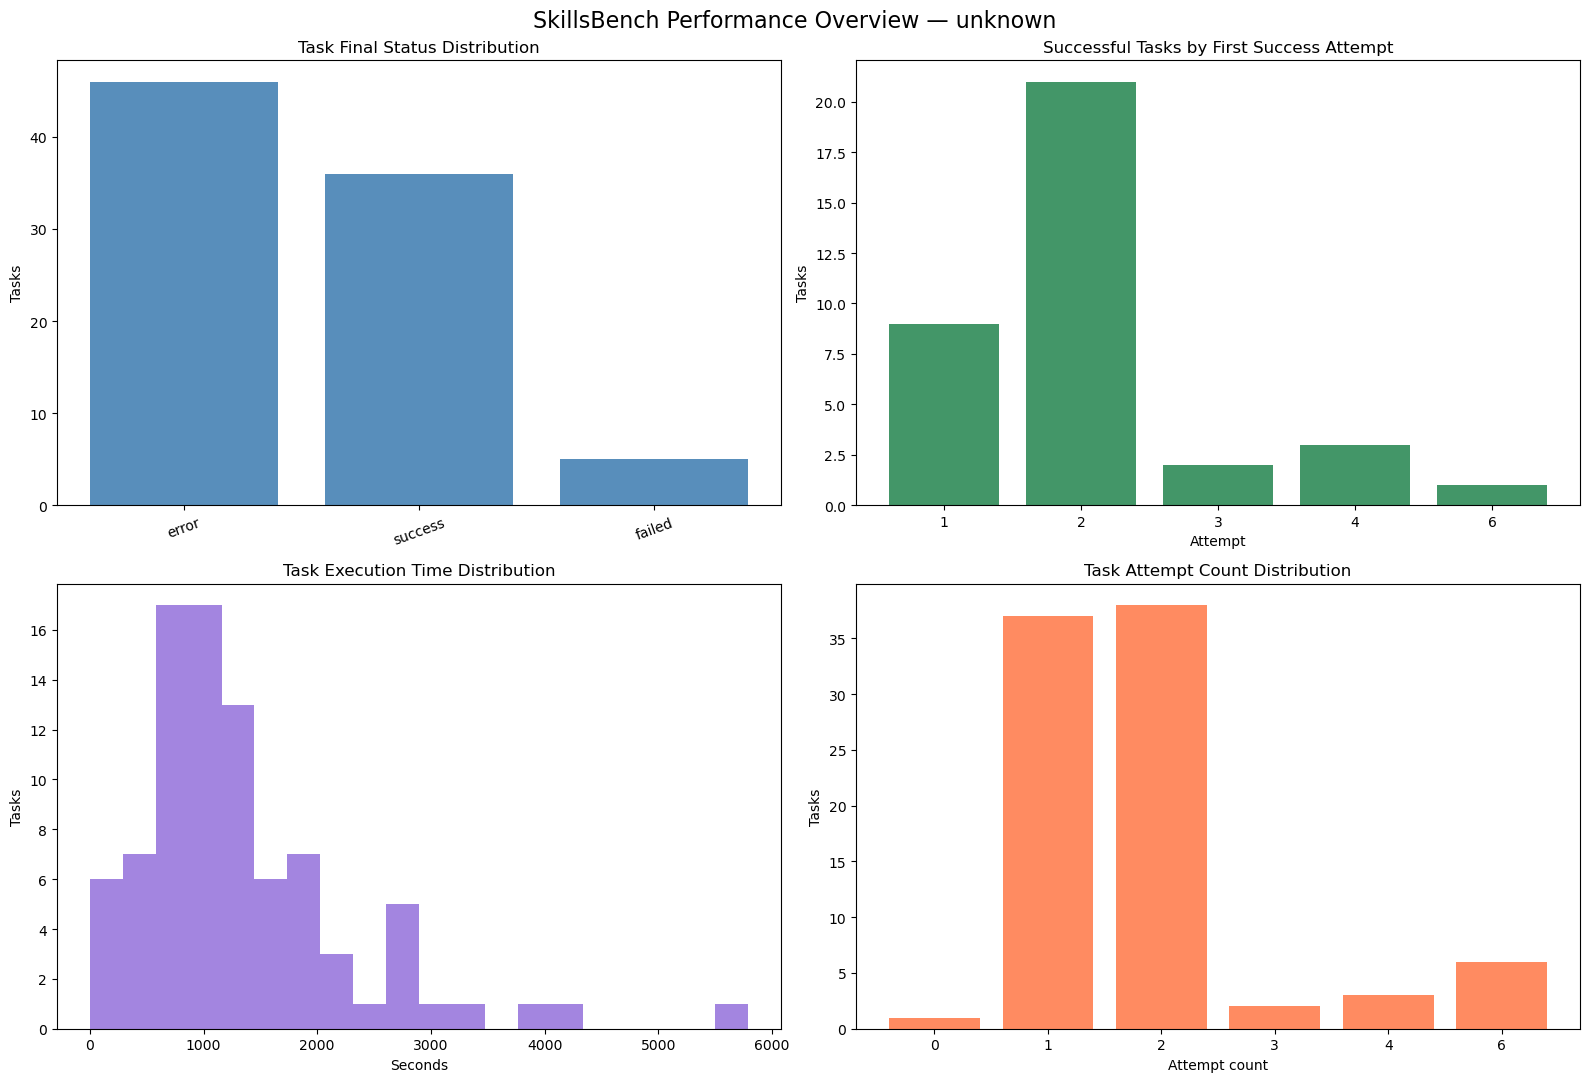

,task_id,status,attempt_count,first_success_attempt,llm_rounds,execution_time_sec,reward,no_effective_attempt,failure_reason
9,powerlifting-coef-calc,success,6,6,80,2680.000000,1.0,False,
0,pg-essay-to-audiobook,success,4,4,127,4183.000000,1.0,False,
16,crystallographic-wyckoff-position-analysis,success,4,4,51,2655.000000,1.0,False,
5,data-to-d3,success,4,4,64,1056.000000,1.0,False,
10,dynamic-object-aware-egomotion,success,3,3,60,1228.000000,1.0,False,
4,simpo-code-reproduction,success,3,3,71,1144.000000,1.0,False,
14,r2r-mpc-control,success,2,2,45,2342.000000,1.0,False,
21,hvac-control,success,2,2,40,2136.000000,1.0,False,
6,video-filler-word-remover,success,2,2,53,2065.000000,1.0,False,
11,latex-formula-extraction,success,2,2,58,1994.000000,1.0,False,


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

status_counts = df_tasks["status"].value_counts().sort_values(ascending=False)
axes[0, 0].bar(status_counts.index, status_counts.values, color="steelblue", alpha=0.9)
axes[0, 0].set_title("Task Final Status Distribution")
axes[0, 0].set_ylabel("Tasks")
axes[0, 0].tick_params(axis="x", rotation=20)

success_by_attempt = (
    df_tasks[df_tasks["success"]]["first_success_attempt"]
    .fillna(0)
    .astype(int)
    .value_counts()
    .sort_index()
)
axes[0, 1].bar(success_by_attempt.index.astype(str), success_by_attempt.values, color="seagreen", alpha=0.9)
axes[0, 1].set_title("Successful Tasks by First Success Attempt")
axes[0, 1].set_xlabel("Attempt")
axes[0, 1].set_ylabel("Tasks")

axes[1, 0].hist(df_tasks["execution_time_sec"], bins=20, color="mediumpurple", alpha=0.85)
axes[1, 0].set_title("Task Execution Time Distribution")
axes[1, 0].set_xlabel("Seconds")
axes[1, 0].set_ylabel("Tasks")

attempt_counts = df_tasks["attempt_count"].value_counts().sort_index()
axes[1, 1].bar(attempt_counts.index.astype(str), attempt_counts.values, color="coral", alpha=0.9)
axes[1, 1].set_title("Task Attempt Count Distribution")
axes[1, 1].set_xlabel("Attempt count")
axes[1, 1].set_ylabel("Tasks")

plt.suptitle(f"SkillsBench Performance Overview — {model}", fontsize=16)
plt.tight_layout()
plt.show()

performance_view = df_tasks.sort_values(["success", "attempt_count", "execution_time_sec"], ascending=[False, False, False])[[
    "task_id", "status", "attempt_count", "first_success_attempt", "llm_rounds",
    "execution_time_sec", "reward", "no_effective_attempt", "failure_reason"
]]

display(performance_view)


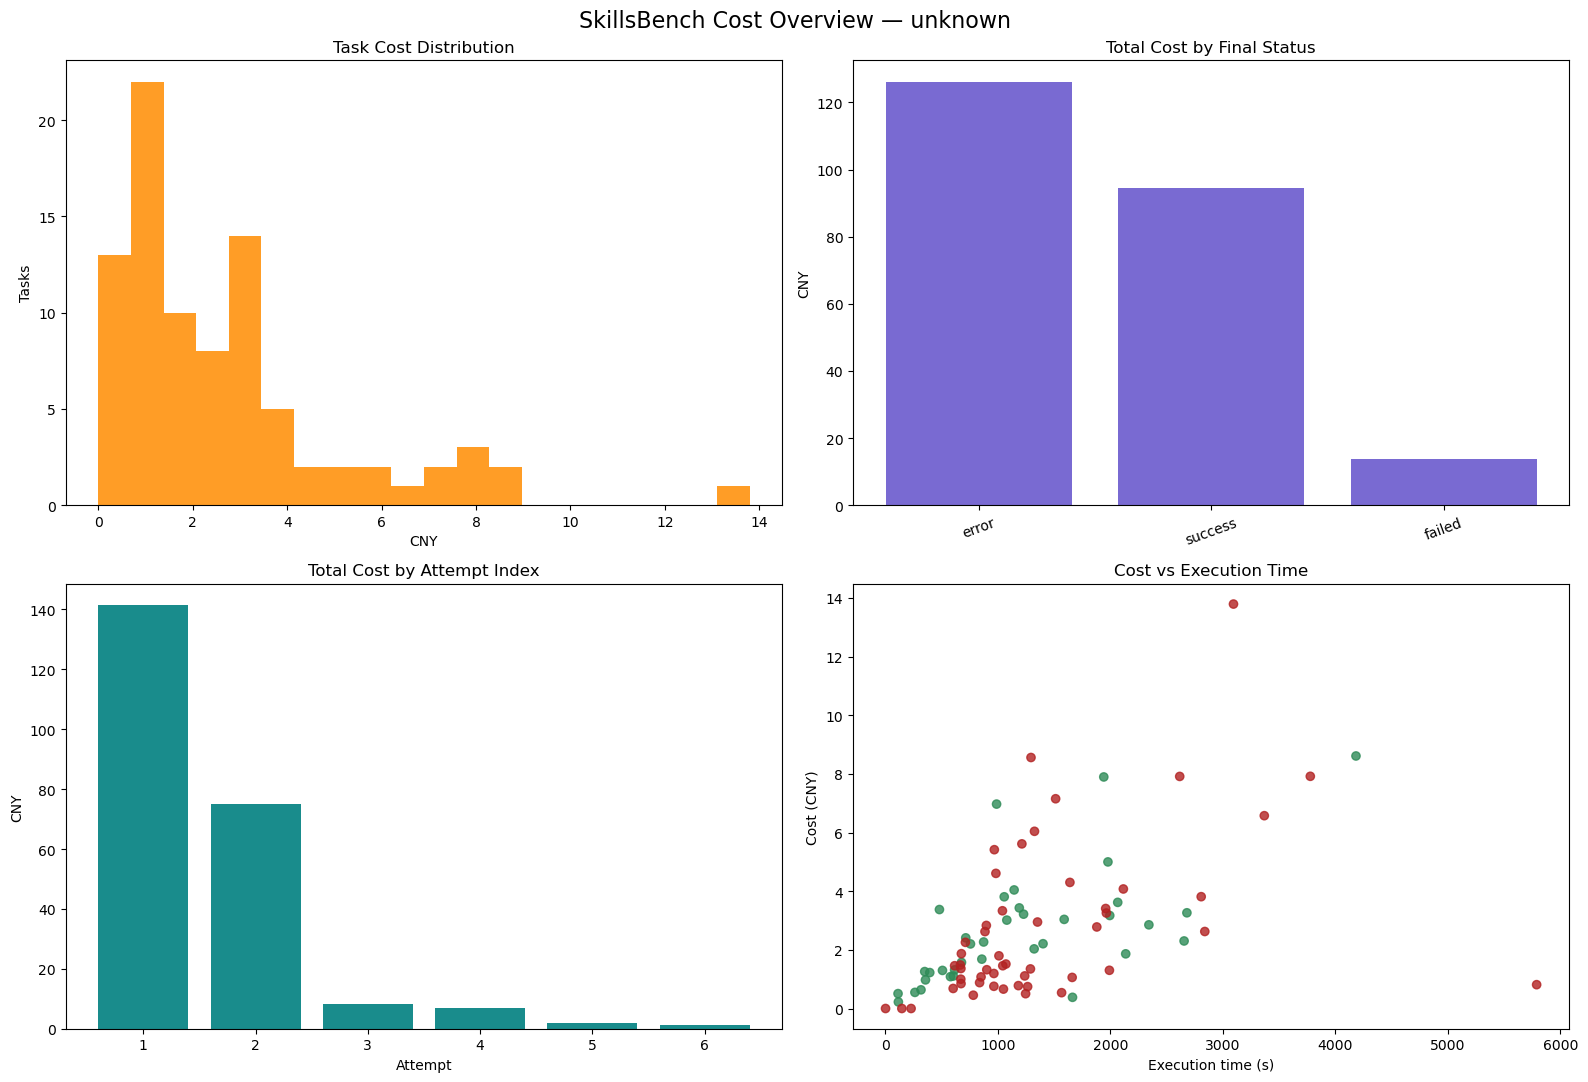

Top 15 most expensive tasks:


,task_id,status,attempt_count,execution_time_sec,input_tokens,output_tokens,cache_read_tokens,total_tokens,cost_cny
36,adaptive-cruise-control,error,2,3094.0,7636509.0,111104.0,7489200.0,15236813.0,13.793422
0,pg-essay-to-audiobook,success,4,4183.0,4905158.0,46963.0,4439488.0,9391609.0,8.612507
37,organize-messy-files,error,2,1294.0,4913310.0,19798.0,4759744.0,9692852.0,8.560009
38,lab-unit-harmonization,error,2,3777.0,4306574.0,93754.0,4088352.0,8488680.0,7.918935
39,setup-fuzzing-py,error,2,2616.0,4504398.0,28973.0,4380912.0,8914283.0,7.914920
1,mars-clouds-clustering,success,1,1941.0,4363221.0,70508.0,4192944.0,8626673.0,7.896732
40,suricata-custom-exfil,error,2,1513.0,4123441.0,27642.0,3668512.0,7819595.0,7.153504
2,court-form-filling,success,2,988.0,3902576.0,45725.0,3778608.0,7726909.0,6.971325
41,fix-build-google-auto,failed,6,3368.0,3733697.0,33777.0,3489120.0,7256594.0,6.575946
42,fix-build-agentops,error,2,1325.0,3431228.0,24580.0,3334976.0,6790784.0,6.043022


Success-task cost total: 94.4352 CNY
Failed-task cost total: 139.8936 CNY
Timed-out task cost total: 117.6879 CNY
Error but non-timeout task cost total: 22.2057 CNY
Cost share on failed tasks: 59.70%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].hist(df_tasks["cost_cny"], bins=20, color="darkorange", alpha=0.85)
axes[0, 0].set_title("Task Cost Distribution")
axes[0, 0].set_xlabel("CNY")
axes[0, 0].set_ylabel("Tasks")

cost_by_status = df_tasks.groupby("status", as_index=False)["cost_cny"].sum().sort_values("cost_cny", ascending=False)
axes[0, 1].bar(cost_by_status["status"], cost_by_status["cost_cny"], color="slateblue", alpha=0.9)
axes[0, 1].set_title("Total Cost by Final Status")
axes[0, 1].set_ylabel("CNY")
axes[0, 1].tick_params(axis="x", rotation=20)

attempt_cost = df_attempts.groupby("attempt", as_index=False)["cost_cny"].sum()
axes[1, 0].bar(attempt_cost["attempt"].astype(str), attempt_cost["cost_cny"], color="teal", alpha=0.9)
axes[1, 0].set_title("Total Cost by Attempt Index")
axes[1, 0].set_xlabel("Attempt")
axes[1, 0].set_ylabel("CNY")

axes[1, 1].scatter(df_tasks["execution_time_sec"], df_tasks["cost_cny"], c=df_tasks["success"].map({True: "seagreen", False: "firebrick"}), alpha=0.8)
axes[1, 1].set_title("Cost vs Execution Time")
axes[1, 1].set_xlabel("Execution time (s)")
axes[1, 1].set_ylabel("Cost (CNY)")

plt.suptitle(f"SkillsBench Cost Overview — {model}", fontsize=16)
plt.tight_layout()
plt.show()

print("Top 15 most expensive tasks:")
display(df_tasks[[
    "task_id", "status", "attempt_count", "execution_time_sec", "input_tokens",
    "output_tokens", "cache_read_tokens", "total_tokens", "cost_cny"
]].sort_values("cost_cny", ascending=False).head(15))

print(f"Success-task cost total: {success_cost_cny:.4f} CNY")
print(f"Failed-task cost total: {failed_cost_cny:.4f} CNY")
print(f"Timed-out task cost total: {timeout_cost_cny:.4f} CNY")
print(f"Error but non-timeout task cost total: {error_non_timeout_cost_cny:.4f} CNY")
print(f"Cost share on failed tasks: {failed_cost_cny / max(success_cost_cny + failed_cost_cny, 1e-9):.2%}")


In [7]:
failed_tasks = df_tasks[~df_tasks["success"]].copy()
failed_reason_summary = failed_tasks.groupby("failure_reason", as_index=False).agg(
    tasks=("task_id", "count"),
    total_cost_cny=("cost_cny", "sum"),
    mean_execution_time_sec=("execution_time_sec", "mean"),
).sort_values(["tasks", "total_cost_cny"], ascending=[False, False])

print("Failure reason summary:")
display(failed_reason_summary)

print("Failure detail:")
display(failed_tasks[[
    "task_id", "status", "timed_out", "attempt_count", "execution_time_sec",
    "cost_cny", "failure_reason", "failure_evidence", "source_trial"
]].sort_values(["failure_reason", "cost_cny"], ascending=[True, False]))


Failure reason summary:


,failure_reason,tasks,total_cost_cny,mean_execution_time_sec
0,unknown,51,139.893617,1409.350832


Failure detail:


,task_id,status,timed_out,attempt_count,execution_time_sec,cost_cny,failure_reason,failure_evidence,source_trial
36,adaptive-cruise-control,error,True,2,3094.000000,13.793422,unknown,missing exception.txt,adaptive-cruise-control__A5gc9an
37,organize-messy-files,error,False,2,1294.000000,8.560009,unknown,missing exception.txt,organize-messy-files__w0vuV3C
38,lab-unit-harmonization,error,True,2,3777.000000,7.918935,unknown,missing exception.txt,lab-unit-harmonization__KsPMR8U
39,setup-fuzzing-py,error,True,2,2616.000000,7.914920,unknown,missing exception.txt,setup-fuzzing-py__ZQNrHl2
40,suricata-custom-exfil,error,True,2,1513.000000,7.153504,unknown,missing exception.txt,suricata-custom-exfil__0jHe4Kc
41,fix-build-google-auto,failed,False,6,3368.000000,6.575946,unknown,missing exception.txt,fix-build-google-auto__T8pjjCo
42,fix-build-agentops,error,True,2,1325.000000,6.043022,unknown,missing exception.txt,fix-build-agentops__XuNsH6W
43,scheduling-email-assistant,error,True,1,1213.000000,5.614766,unknown,missing exception.txt,scheduling-email-assistant__owSOAuV
44,lean4-proof,error,True,2,968.000000,5.416205,unknown,missing exception.txt,lean4-proof__IlKI5dm
45,pedestrian-traffic-counting,error,True,1,982.000000,4.608488,unknown,missing exception.txt,pedestrian-traffic-counting__LCVcirz


In [8]:
# 动态停止策略（SkillsBench-87 MiniMax）：当某次 attempt 的 score_delta == 0.0 时，在该次后停止累计后续 attempt
import pandas as pd

def _dynamic_cut_attempts_by_flat_delta(task):
    kept = []
    for attempt in task.get('attempts') or []:
        kept.append(attempt)
        delta = attempt.get('score_delta')
        if delta is not None and float(delta) == 0.0:
            break
    return kept

def _dynamic_first_success_attempt(task):
    first_success_attempt = task.get('first_success_attempt')
    if first_success_attempt is None:
        return None
    kept = _dynamic_cut_attempts_by_flat_delta(task)
    cutoff_attempt = max((int(a.get('attempt') or 0) for a in kept), default=0)
    return int(first_success_attempt) if int(first_success_attempt) <= cutoff_attempt else None

dynamic_full_rows = []
for task in tasks:
    kept_attempts = _dynamic_cut_attempts_by_flat_delta(task)
    dynamic_fsa = _dynamic_first_success_attempt(task)
    dynamic_cost = sum(compute_cost(((attempt.get('execution') or {}).get('usage') or attempt.get('usage') or {})) for attempt in kept_attempts)
    dynamic_full_rows.append({
        'task_id': task.get('task_id', ''),
        'original_attempt_count': int(task.get('attempt_count') or len(task.get('attempts') or [])),
        'dynamic_attempt_count': len(kept_attempts),
        'success_standard': bool(task.get('success_within_budget')),
        'success_dynamic': dynamic_fsa is not None,
        'cost_cny_standard': sum(compute_cost(((attempt.get('execution') or {}).get('usage') or attempt.get('usage') or {})) for attempt in (task.get('attempts') or [])),
        'cost_cny_dynamic': dynamic_cost,
        'truncated': len(kept_attempts) < int(task.get('attempt_count') or len(task.get('attempts') or [])),
    })

dynamic_full_df = pd.DataFrame(dynamic_full_rows)
dynamic_full_summary = {
    'task_count': int(len(dynamic_full_df)),
    'success_count_standard': int(dynamic_full_df['success_standard'].sum()),
    'success_count_dynamic': int(dynamic_full_df['success_dynamic'].sum()),
    'success_rate_standard': float(dynamic_full_df['success_standard'].mean()),
    'success_rate_dynamic': float(dynamic_full_df['success_dynamic'].mean()),
    'total_cost_cny_standard': float(dynamic_full_df['cost_cny_standard'].sum()),
    'total_cost_cny_dynamic': float(dynamic_full_df['cost_cny_dynamic'].sum()),
    'mean_cost_cny_standard': float(dynamic_full_df['cost_cny_standard'].mean()),
    'mean_cost_cny_dynamic': float(dynamic_full_df['cost_cny_dynamic'].mean()),
    'truncated_task_count': int(dynamic_full_df['truncated'].sum()),
}
for key, value in dynamic_full_summary.items():
    print(f'{key}: {value}')

print('Dynamic-stop truncation details:')
display(dynamic_full_df.sort_values(['truncated', 'cost_cny_standard', 'task_id'], ascending=[False, False, True]).reset_index(drop=True))


task_count: 87
success_count_standard: 36
success_count_dynamic: 30
success_rate_standard: 0.41379310344827586
success_rate_dynamic: 0.3448275862068966
total_cost_cny_standard: 234.32881420799995
total_cost_cny_dynamic: 216.36864835199995
mean_cost_cny_standard: 2.693434646068965
mean_cost_cny_dynamic: 2.486995958068965
truncated_task_count: 11
Dynamic-stop truncation details:


,task_id,original_attempt_count,dynamic_attempt_count,success_standard,success_dynamic,cost_cny_standard,cost_cny_dynamic,truncated
0,pg-essay-to-audiobook,4,2,True,False,8.612507,3.810123,True
1,fix-build-google-auto,6,2,False,False,6.575946,3.900692,True
2,simpo-code-reproduction,3,2,True,False,4.043564,2.613982,True
3,pptx-reference-formatting,6,2,False,False,3.813565,3.269263,True
4,data-to-d3,4,2,True,False,3.809178,1.472053,True
5,powerlifting-coef-calc,6,2,True,False,3.263877,2.210442,True
6,invoice-fraud-detection,6,2,False,False,3.256148,1.562018,True
7,dynamic-object-aware-egomotion,3,2,True,False,3.217700,0.580310,True
8,crystallographic-wyckoff-position-analysis,4,2,True,False,2.303275,1.516711,True
9,pddl-tpp-planning,6,1,False,False,0.000000,0.000000,True


In [9]:
# 32-task cost-aware stratified subset for paper experiments
import tomllib

SUBSET_32_TASKS = [
    "threejs-structure-parser",
    "python-scala-translation",
    "fix-build-google-auto",
    "fix-build-agentops",
    "court-form-filling",
    "dialogue-parser",
    "powerlifting-coef-calc",
    "earthquake-phase-association",
    "dapt-intrusion-detection",
    "setup-fuzzing-py",
    "software-dependency-audit",
    "suricata-custom-exfil",
    "r2r-mpc-control",
    "energy-market-pricing",
    "financial-modeling-qa",
    "find-topk-similiar-chemicals",
    "react-performance-debugging",
    "glm-lake-mendota",
    "lake-warming-attribution",
    "latex-formula-extraction",
    "lean4-proof",
    "manufacturing-equipment-maintenance",
    "manufacturing-codebook-normalization",
    "mars-clouds-clustering",
    "offer-letter-generator",
    "parallel-tfidf-search",
    "pedestrian-traffic-counting",
    "quantum-numerical-simulation",
    "shock-analysis-demand",
    "reserves-at-risk-calc",
    "sec-financial-report",
    "spring-boot-jakarta-migration",
]

EXCLUDED_AS_COST_OUTLIERS = [
    "lab-unit-harmonization",
    "manufacturing-fjsp-optimization",
    "adaptive-cruise-control",
    "pddl-tpp-planning",
]

EXCLUDED_AS_ZERO_TOKEN_IMPUTED = [
    "video-tutorial-indexer",
    "virtualhome-agent-planning",
    "weighted-gdp-calc",
    "xlsx-recover-data",
]

task_meta_rows = []
for task_id in SUBSET_32_TASKS:
    task_toml = tomllib.loads((Path('/home/nudt/lirui/skill_study/skillsbench/tasks') / task_id / 'task.toml').read_text(encoding='utf-8'))
    metadata = task_toml.get('metadata', {})
    task_meta_rows.append({
        'task_id': task_id,
        'category': metadata.get('category', 'unknown'),
        'difficulty': metadata.get('difficulty', 'unknown'),
        'tags': ', '.join(metadata.get('tags', [])),
    })

df_subset_meta = pd.DataFrame(task_meta_rows)
df_subset = df_tasks[df_tasks['task_id'].isin(SUBSET_32_TASKS)].copy()
meta_by_task = df_subset_meta.set_index('task_id').to_dict(orient='index')
df_subset['category'] = df_subset['task_id'].map(lambda t: meta_by_task.get(t, {}).get('category', 'unknown'))
df_subset['difficulty'] = df_subset['task_id'].map(lambda t: meta_by_task.get(t, {}).get('difficulty', 'unknown'))
df_subset['tags'] = df_subset['task_id'].map(lambda t: meta_by_task.get(t, {}).get('tags', ''))

if len(df_subset) != len(SUBSET_32_TASKS):
    missing = sorted(set(SUBSET_32_TASKS) - set(df_subset['task_id']))
    raise ValueError(f'Subset task count mismatch: expected {len(SUBSET_32_TASKS)}, got {len(df_subset)}; missing={missing}')

subset_summary = {
    'subset_task_count': int(len(df_subset)),
    'subset_success_count': int(df_subset['success'].sum()),
    'subset_failure_count': int((~df_subset['success']).sum()),
    'subset_success_rate': float(df_subset['success'].mean()),
    'subset_total_cost_cny': float(df_subset['cost_cny'].sum()),
    'subset_mean_cost_cny': float(df_subset['cost_cny'].mean()),
    'subset_median_cost_cny': float(df_subset['cost_cny'].median()),
    'subset_success_cost_cny': float(df_subset.loc[df_subset['success'], 'cost_cny'].sum()),
    'subset_failure_cost_cny': float(df_subset.loc[~df_subset['success'], 'cost_cny'].sum()),
}

print('32-task subset summary for MiniMax-M2.5:')
for key, value in subset_summary.items():
    print(f'  {key}: {value}')

print('\nCategory distribution:')
display(df_subset.groupby('category').size().rename('tasks').sort_values(ascending=False).reset_index())

print('Difficulty distribution:')
display(df_subset.groupby('difficulty').size().rename('tasks').sort_values(ascending=False).reset_index())

display(
    df_subset[[
        'task_id', 'category', 'difficulty', 'success', 'reward', 'cost_cny',
        'attempt_count', 'execution_time_sec', 'input_tokens', 'output_tokens', 'total_tokens'
    ]]
    .sort_values(['category', 'cost_cny', 'task_id'], ascending=[True, False, True])
    .reset_index(drop=True)
)


ModuleNotFoundError: No module named 'tomllib'